23070521064 -Jay

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving test.csv to test.csv
Saving train.csv to train.csv


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [ ]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
print(train.shape)

(1460, 81)


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [ ]:
train.isnull().sum().sort_values(ascending=False)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


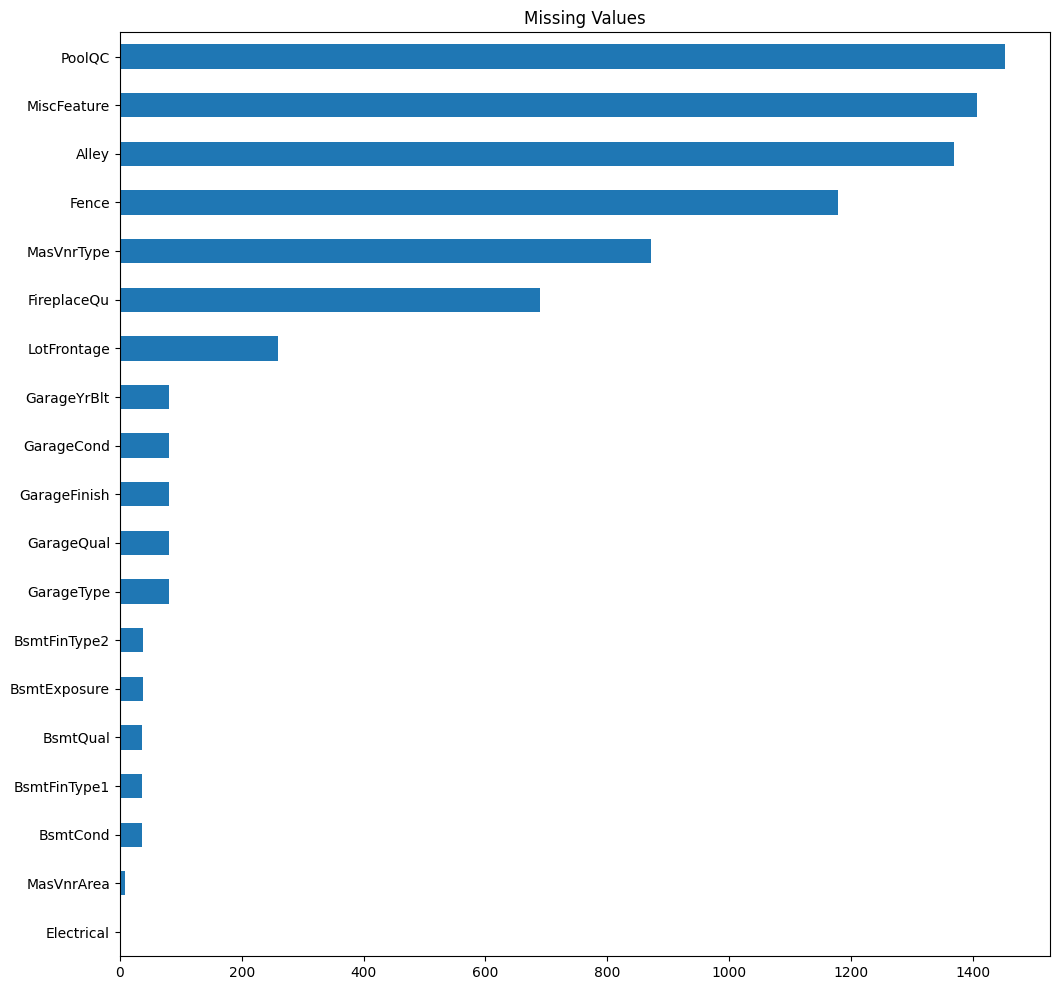

In [ ]:
missing = train.isnull().sum()

missing = missing[missing>0]

missing.sort_values().plot(kind='barh', figsize=(12,12))

plt.title("Missing Values")

plt.show()

In [ ]:
train.drop("Id", axis=1, inplace=True)
test.drop("Id", axis=1, inplace=True)

In [ ]:
num_cols = train.select_dtypes(include=['int64','float64']).columns

cat_cols = train.select_dtypes(include=['object']).columns

print(len(num_cols))
print(len(cat_cols))

37
43


In [ ]:
for col in num_cols:
    train[col].fillna(train[col].median(), inplace=True)

    if col in test.columns:
        test[col].fillna(test[col].median(), inplace=True)

/tmp/ipykernel_3342/1178445350.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train[col].fillna(train[col].median(), inplace=True)
/tmp/ipykernel_3342/1178445350.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

In [ ]:
for col in cat_cols:
    train[col].fillna(train[col].mode()[0], inplace=True)

    if col in test.columns:
        test[col].fillna(test[col].mode()[0], inplace=True)

/tmp/ipykernel_3342/3213121430.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train[col].fillna(train[col].mode()[0], inplace=True)
/tmp/ipykernel_3342/3213121430.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)',

In [ ]:
encoder = LabelEncoder()

for col in cat_cols:

    train[col] = encoder.fit_transform(train[col])

    if col in test.columns:
        test[col] = encoder.fit_transform(test[col])

In [ ]:
X = train.drop("SalePrice", axis=1)

y = train["SalePrice"]

In [ ]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

test_scaled = scaler.transform(test)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(

X,

y,

test_size=0.20,

random_state=42
)

In [ ]:
model = Sequential()

model.add(Dense(128,
                activation='relu',
                input_shape=(X_train.shape[1],)))

model.add(Dense(64,
                activation='relu'))

model.add(Dense(32,
                activation='relu'))

model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(

optimizer='adam',

loss='mse',

metrics=['mae']

)

In [ ]:
history = model.fit(

X_train,

y_train,

epochs=100,

batch_size=32,

validation_split=0.2,

verbose=1

)

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 39146008576.0000 - mae: 181523.9219 - val_loss: 37839110144.0000 - val_mae: 181094.2188
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 39137329152.0000 - mae: 181502.9531 - val_loss: 37818363904.0000 - val_mae: 181046.5156
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 39085944832.0000 - mae: 181391.2188 - val_loss: 37715787776.0000 - val_mae: 180825.4688
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 38872383488.0000 - mae: 180943.9531 - val_loss: 37354086400.0000 - val_mae: 180062.4062
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 38257799168.0000 - mae: 179660.5000 - val_loss: 36442656768.0000 - val_mae: 178132.5312
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 36819591168.0000 - mae: 176654.4219 - val_loss: 34543546368.0000 - val_mae: 174008.4844
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 34164162560.0000 - mae: 170804.7344 - val_loss: 312063

In [ ]:
pred = model.predict(X_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


In [ ]:
mae = mean_absolute_error(y_test,pred)

In [ ]:
mse = mean_squared_error(y_test,pred)

In [ ]:
rmse = np.sqrt(mse)

In [ ]:
print("MAE :",mae)

print("MSE :",mse)

print("RMSE :",rmse)

MAE : 25922.138671875
MSE : 1431363968.0
RMSE : 37833.371089555316


In [ ]:
test_predictions = model.predict(test_scaled)

test_predictions[:10]

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


array([[323832.5 ],
       [268018.66],
       [502601.1 ],
       [526897.6 ],
       [473662.75],
       [508128.6 ],
       [511150.7 ],
       [493595.44],
       [484780.3 ],
       [364014.16]], dtype=float32)

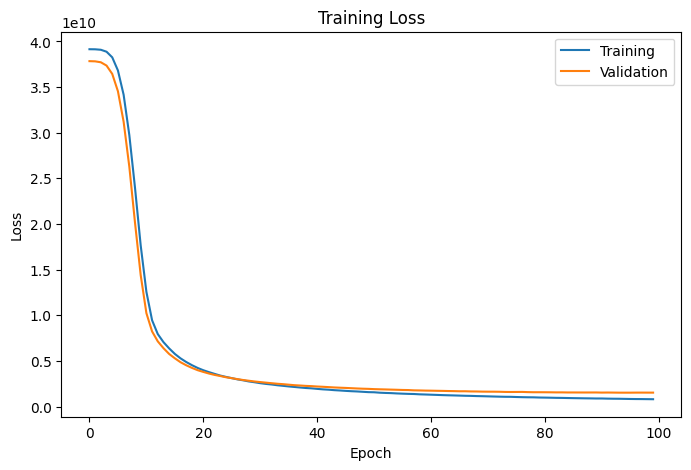

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.legend(["Training","Validation"])

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.show()

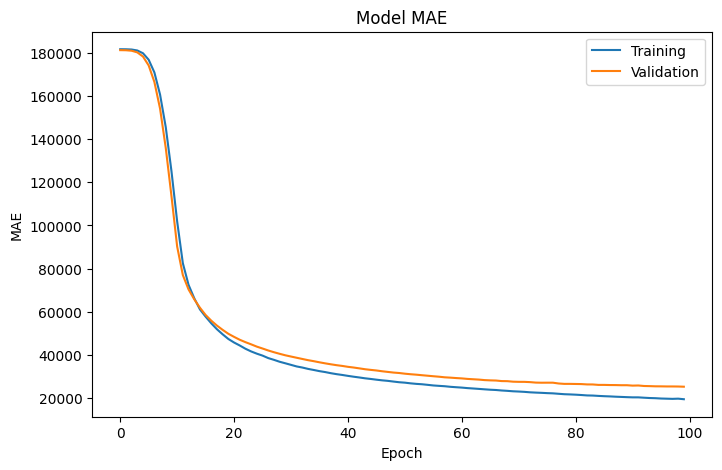

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['mae'])

plt.plot(history.history['val_mae'])

plt.legend(["Training","Validation"])

plt.xlabel("Epoch")

plt.ylabel("MAE")

plt.title("Model MAE")

plt.show()

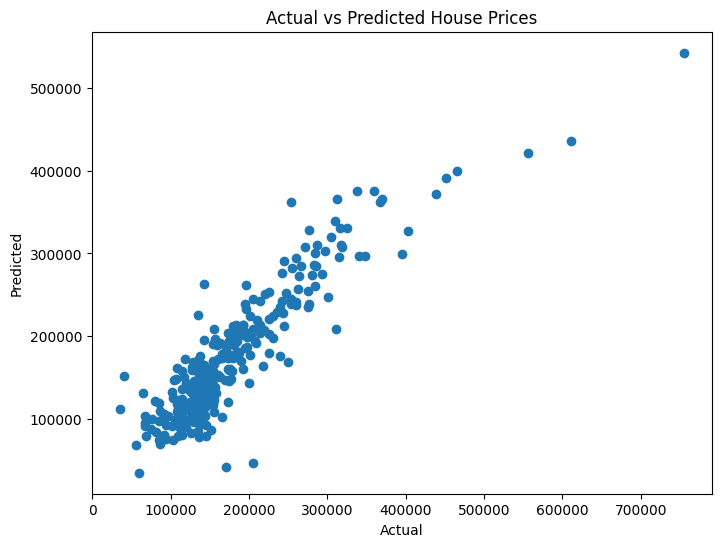

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_test,pred)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted House Prices")

plt.show()

In [ ]:
model1 = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(1)
])

model1.compile(optimizer='adam',
               loss='mse',
               metrics=['mae'])

history1 = model1.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

pred1 = model1.predict(X_test)

mae1 = mean_absolute_error(y_test, pred1)
mse1 = mean_squared_error(y_test, pred1)
rmse1 = np.sqrt(mse1)

print("Model 1")
print("MAE :", mae1)
print("MSE :", mse1)
print("RMSE:", rmse1)

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 39146930176.0000 - mae: 181526.7031 - val_loss: 37841772544.0000 - val_mae: 181101.5156
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 39146090496.0000 - mae: 181524.9062 - val_loss: 37840932864.0000 - val_mae: 181099.7500
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 39145054208.0000 - mae: 181522.7656 - val_loss: 37839802368.0000 - val_mae: 181097.3281
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 39143661568.0000 - mae: 181519.8906 - val_loss: 37838249984.0000 - val_mae: 181094.1250
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 39141806080.0000 - mae: 181516.2188 - val_loss: 37836242944.0000 - val_mae: 181090.0469
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 39139389440.0000 - mae: 181511.4219 - val_loss: 37833691136.0000 - val_mae: 181084.8906
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 39136411648.0000 - mae: 181505.5469 - val_loss: 3783

In [ ]:
model2 = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(1)
])

model2.compile(optimizer='adam',
               loss='mse',
               metrics=['mae'])

history2 = model2.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

pred2 = model2.predict(X_test)

mae2 = mean_absolute_error(y_test, pred2)
mse2 = mean_squared_error(y_test, pred2)
rmse2 = np.sqrt(mse2)

print("Model 2")
print("MAE :", mae2)
print("MSE :", mse2)
print("RMSE:", rmse2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 39145959424.0000 - mae: 181524.0469 - val_loss: 37839454208.0000 - val_mae: 181095.6250
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 39140995072.0000 - mae: 181513.0625 - val_loss: 37831282688.0000 - val_mae: 181077.9844
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 39125487616.0000 - mae: 181481.3594 - val_loss: 37807296512.0000 - val_mae: 181028.7969
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 39085543424.0000 - mae: 181401.8125 - val_loss: 37752147968.0000 - val_mae: 180917.5312
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 39004684288.0000 - mae: 181239.9375 - val_loss: 37644955648.0000 - val_mae: 180702.5000
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 38859718656.0000 - mae: 180958.2344 - val_loss: 37470969856.0000 - val_mae: 180353.4688
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 38629232640.0000 - mae: 180501.2812 - val_loss: 37210492

In [ ]:
model3 = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

model3.compile(optimizer='adam',
               loss='mse',
               metrics=['mae'])

history3 = model3.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

pred3 = model3.predict(X_test)

mae3 = mean_absolute_error(y_test, pred3)
mse3 = mean_squared_error(y_test, pred3)
rmse3 = np.sqrt(mse3)

print("Model 3")
print("MAE :", mae3)
print("MSE :", mse3)
print("RMSE:", rmse3)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 39144972288.0000 - mae: 181521.4844 - val_loss: 37836296192.0000 - val_mae: 181087.6250
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 39129006080.0000 - mae: 181484.3750 - val_loss: 37801259008.0000 - val_mae: 181008.5938
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 39046221824.0000 - mae: 181305.0312 - val_loss: 37644144640.0000 - val_mae: 180674.1562
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 38737534976.0000 - mae: 180668.3125 - val_loss: 37144014848.0000 - val_mae: 179628.6094
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 37884350464.0000 - mae: 178923.6562 - val_loss: 35943092224.0000 - val_mae: 177095.0156
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 36021796864.0000 - mae: 175029.9688 - val_loss: 33491961856.0000 - val_mae: 171767.7812
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 32728758272.0000 - mae: 167587.2188 - val_loss: 29413234688.0000 - val

In [ ]:
model4 = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

model4.compile(optimizer='adam',
               loss='mse',
               metrics=['mae'])

history4 = model4.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

pred4 = model4.predict(X_test)

mae4 = mean_absolute_error(y_test, pred4)
mse4 = mean_squared_error(y_test, pred4)
rmse4 = np.sqrt(mse4)

print("Model 4")
print("MAE :", mae4)
print("MSE :", mse4)
print("RMSE:", rmse4)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 39140454400.0000 - mae: 181510.2188 - val_loss: 37815341056.0000 - val_mae: 181036.5781
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 38989680640.0000 - mae: 181167.0781 - val_loss: 37339906048.0000 - val_mae: 179976.9844
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 37294551040.0000 - mae: 177466.2656 - val_loss: 33388709888.0000 - val_mae: 171177.2969
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 27826348032.0000 - mae: 155037.0312 - val_loss: 18073968640.0000 - val_mae: 128774.9219
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 11215700992.0000 - mae: 90504.1484 - val_loss: 6468190208.0000 - val_mae: 68775.4922
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5934710784.0000 - mae: 58811.0586 - val_loss: 4431549952.0000 - val_mae: 53879.8828
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4357411840.0000 - mae: 48646.9961 - val_loss: 3303579136.0000 - val_mae: 456

In [ ]:
model5 = Sequential([
    Dense(512, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

model5.compile(optimizer='adam',
               loss='mse',
               metrics=['mae'])

history5 = model5.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

pred5 = model5.predict(X_test)

mae5 = mean_absolute_error(y_test, pred5)
mse5 = mean_squared_error(y_test, pred5)
rmse5 = np.sqrt(mse5)

print("Model 5")
print("MAE :", mae5)
print("MSE :", mse5)
print("RMSE:", rmse5)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 39115079680.0000 - mae: 181450.6719 - val_loss: 37641576448.0000 - val_mae: 180630.5156
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 36438495232.0000 - mae: 175573.8594 - val_loss: 27832424448.0000 - val_mae: 157804.8594
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 13376190464.0000 - mae: 100705.2188 - val_loss: 5541607424.0000 - val_mae: 63459.9883
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4159389952.0000 - mae: 45088.9531 - val_loss: 2190015232.0000 - val_mae: 37218.7734
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2908819712.0000 - mae: 39651.4102 - val_loss: 1759357056.0000 - val_mae: 32360.8418
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1836234496.0000 - mae: 28320.9902 - val_loss: 1519211392.0000 - val_mae: 29597.9453
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1557920384.0000 - mae: 25654.2148 - val_loss: 1382282496.0000 - val_mae: 27682.9

In [ ]:
results = pd.DataFrame({
    "Model": ["1 Layer","2 Layers","3 Layers","4 Layers","5 Layers"],
    "MAE": [mae1, mae2, mae3, mae4, mae5],
    "MSE": [mse1, mse2, mse3, mse4, mse5],
    "RMSE": [rmse1, rmse2, rmse3, rmse4, rmse5]
})

results

,Model,MAE,MSE,RMSE
0,1 Layer,170618.750000,3.582124e+10,189265.011072
1,2 Layers,37901.308594,2.434755e+09,49343.239942
2,3 Layers,25931.859375,1.417117e+09,37644.608432
3,4 Layers,20371.253906,1.131706e+09,33640.843747
4,5 Layers,21462.736328,1.254356e+09,35416.893596


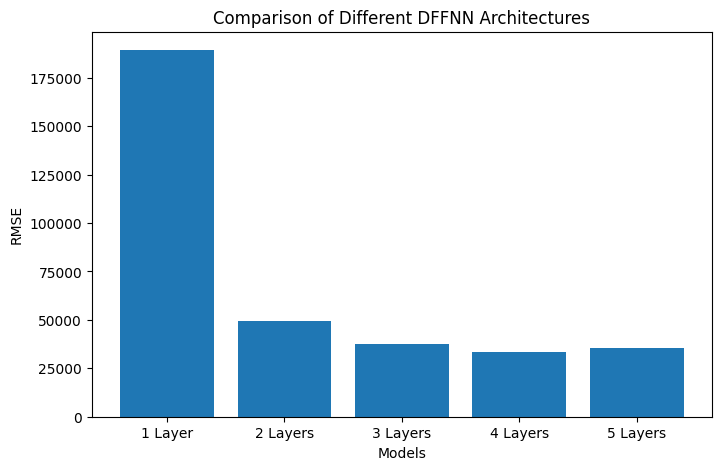

In [ ]:
models = ['1 Layer', '2 Layers', '3 Layers', '4 Layers', '5 Layers']

rmse_values = [rmse1, rmse2, rmse3, rmse4, rmse5]

plt.figure(figsize=(8,5))
plt.bar(models, rmse_values)

plt.xlabel("Models")
plt.ylabel("RMSE")
plt.title("Comparison of Different DFFNN Architectures")

plt.show()

Extra Work

Training 1 Layer


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


MAE  : 170835.70
MSE  : 35712987136.00
RMSE : 188978.80

Training 2 Layers


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


MAE  : 35607.21
MSE  : 2170924032.00
RMSE : 46593.18

Training 3 Layers


...

MAE  : 26054.71
MSE  : 1429661568.00
RMSE : 37810.87

Training 4 Layers


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


MAE  : 20764.15
MSE  : 1161728896.00
RMSE : 34084.14

Training 5 Layers


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


MAE  : 21558.16
MSE  : 1241198720.00
RMSE : 35230.65


Final Comparison Table

      Model            MAE           MSE           RMSE
0   1 Layer  170835.703125  3.571299e+10  188978.800758
1  2 Layers   35607.210938  2.170924e+09   46593.175809
2  3 Layers   26054.714844  1.429662e+09   37810.865740
3  4 Layers   20764.152344  1.161729e+09   34084.144349
4  5 Layers   21558.164062  1.241199e+09   35230.650292

Best Model
Model        4 Layers
MAE      20764.152344
MSE      1161728896.0
RMSE     34084.144349
Name: 3, dtype: object


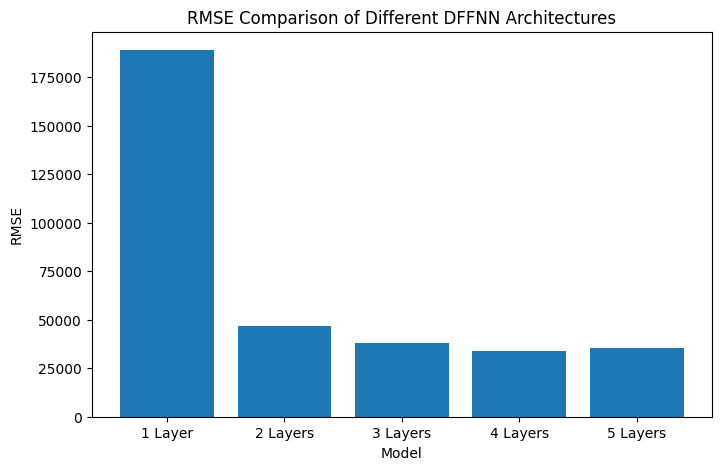

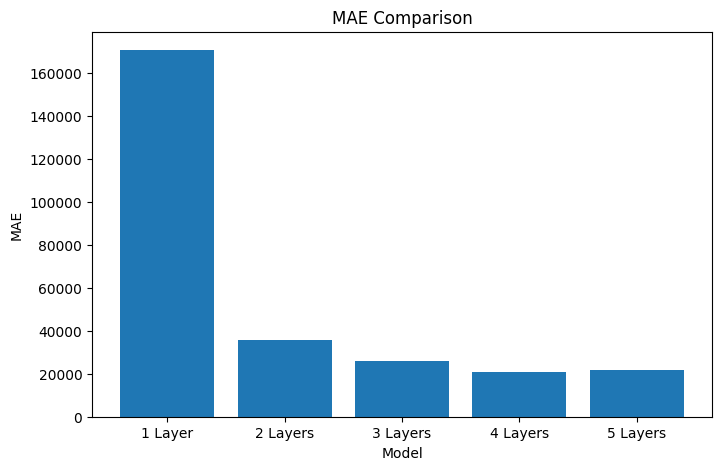

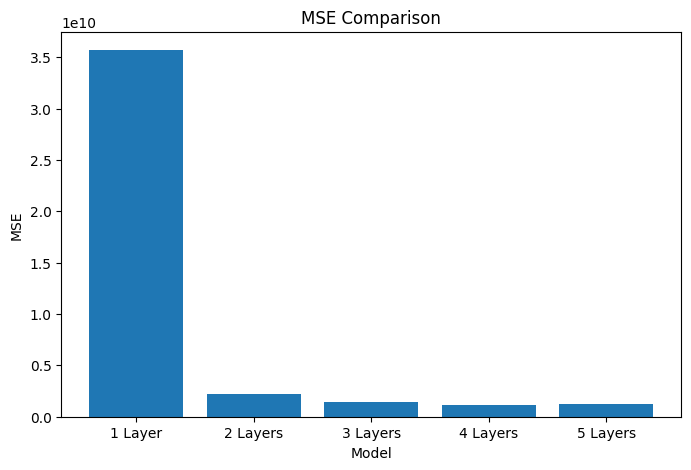

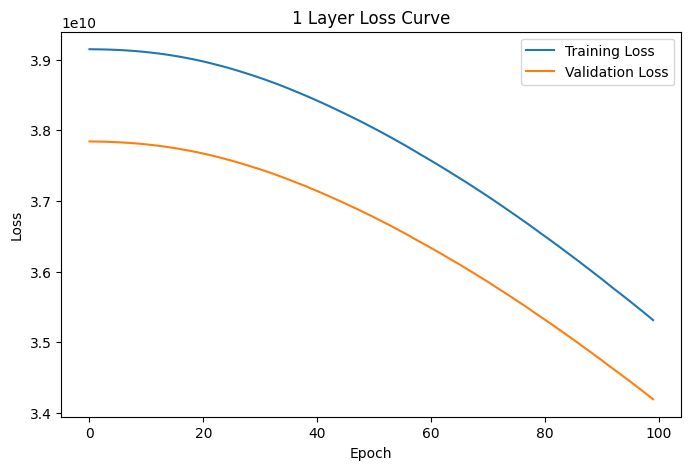

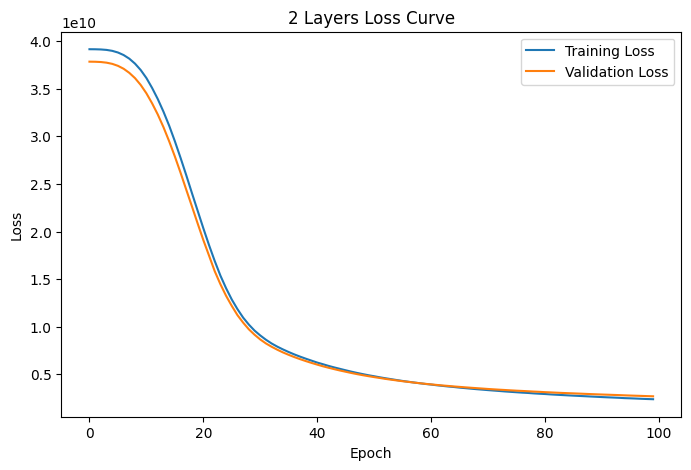

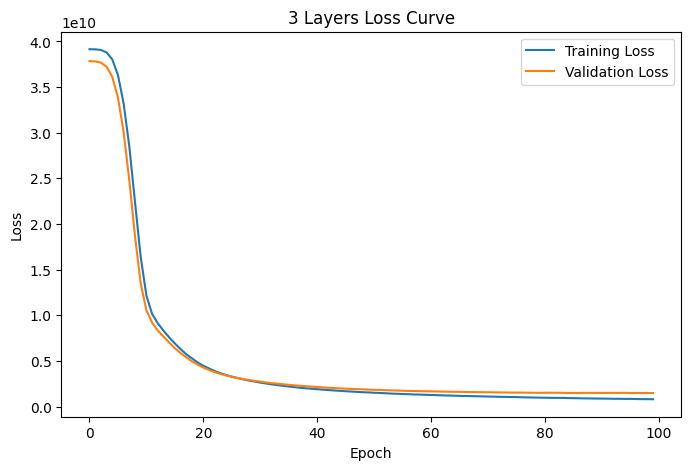

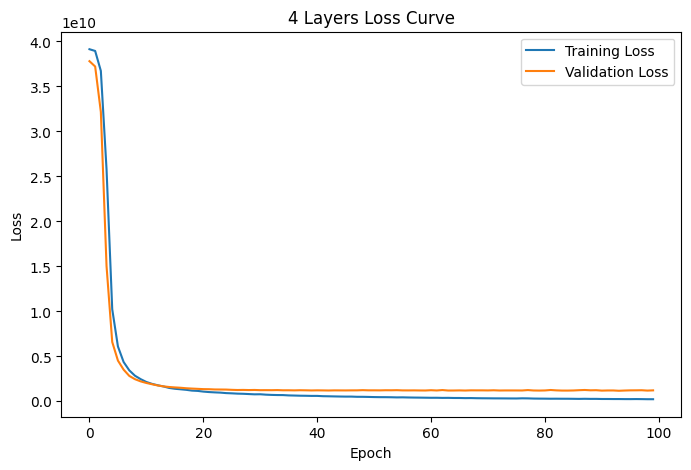

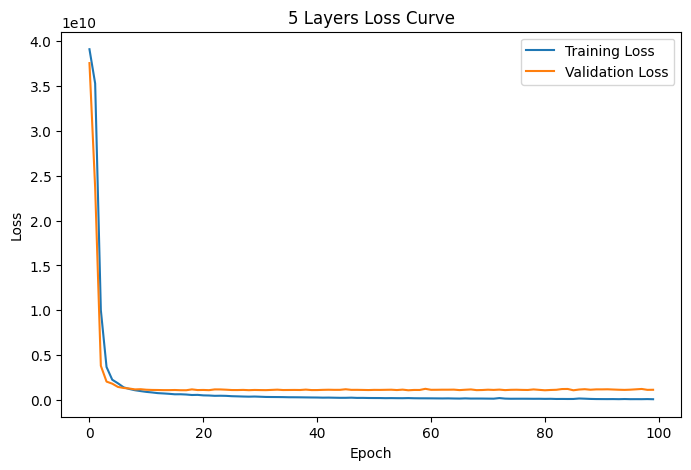

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


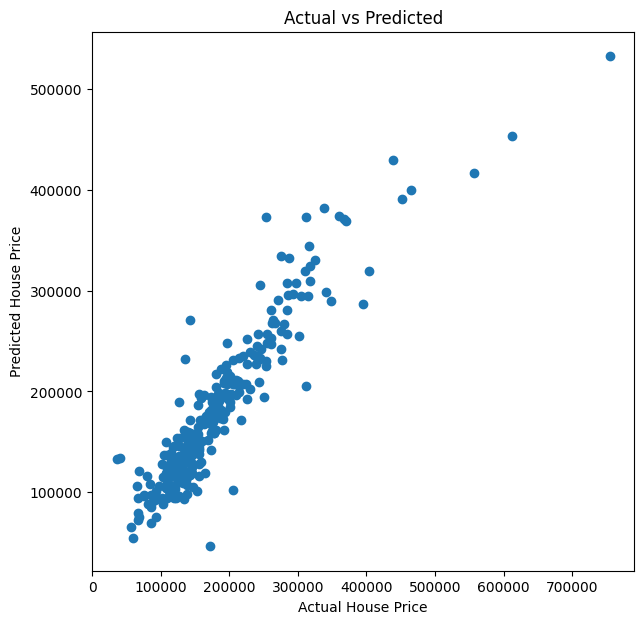

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Different DFFNN architectures
architectures = {
    "1 Layer": [64],
    "2 Layers": [128, 64],
    "3 Layers": [128, 64, 32],
    "4 Layers": [256, 128, 64, 32],
    "5 Layers": [512, 256, 128, 64, 32]
}

results = []

histories = {}

for name, layers in architectures.items():

    print("="*60)
    print(f"Training {name}")
    print("="*60)

    model = Sequential()

    # Input Layer
    model.add(Dense(layers[0],
                    activation='relu',
                    input_shape=(X_train.shape[1],)))

    # Hidden Layers
    for neurons in layers[1:]:
        model.add(Dense(neurons, activation='relu'))

    # Output Layer
    model.add(Dense(1))

    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )

    history = model.fit(
        X_train,
        y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )

    histories[name] = history

    predictions = model.predict(X_test, verbose=0)

    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)

    results.append([name, mae, mse, rmse])

    print(f"MAE  : {mae:.2f}")
    print(f"MSE  : {mse:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print()

# Comparison Table
results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "MSE", "RMSE"]
)

print("\nFinal Comparison Table\n")
print(results_df)

# Best Model
best = results_df.loc[results_df["RMSE"].idxmin()]

print("\nBest Model")
print(best)

# RMSE Bar Graph
plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.title("RMSE Comparison of Different DFFNN Architectures")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.show()

# MAE Bar Graph
plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["MAE"])
plt.title("MAE Comparison")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.show()

# MSE Bar Graph
plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["MSE"])
plt.title("MSE Comparison")
plt.xlabel("Model")
plt.ylabel("MSE")
plt.show()

# Loss Curves for all models
for name in histories:
    plt.figure(figsize=(8,5))
    plt.plot(histories[name].history['loss'], label='Training Loss')
    plt.plot(histories[name].history['val_loss'], label='Validation Loss')
    plt.title(f'{name} Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

# Actual vs Predicted for Best Model
best_layers = architectures[best["Model"]]

best_model = Sequential()

best_model.add(Dense(best_layers[0],
                     activation='relu',
                     input_shape=(X_train.shape[1],)))

for neurons in best_layers[1:]:
    best_model.add(Dense(neurons, activation='relu'))

best_model.add(Dense(1))

best_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

best_model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

best_predictions = best_model.predict(X_test, verbose=0)

plt.figure(figsize=(7,7))
plt.scatter(y_test, best_predictions)
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted")
plt.show()